# LOAD LIBRARIES

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits,
    rfe_selection
)

# CONFIGURATION

In [22]:
START_DATE, END_DATE = '2023-10-18', '2024-08-22'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = True
UNDERSAMPLE = False
ADD_ID = False
ADD_TRT = True
ADD_CANOPY = False

# LOAD DATA

In [23]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.364 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-10-18 to 2024-08-22

Target column: FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-18 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
2023-10-18 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25
2023-10-18 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26
2023-10-18 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27
2023-10-18 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,NaN,4.785047,4.785047,4.861709,0.076663,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.0,0.0,14899
2024-08-22 22:15:00,NaN,NaN,4.913285,4.913285,4.809273,-0.104013,2.623038,2.623038,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.0,0.0,14900
2024-08-22 22:45:00,NaN,NaN,4.913285,4.913285,4.806984,-0.106301,1.743544,1.743544,1.743544,NaN,NaN,NaN,B,certain,1.0,...,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.0,0.0,14901


# CLEAN DATA

In [24]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

# Remove teatment variable if ADD_TRT==False
if ADD_TRT==False:
    data.drop(columns='trt', inplace=True)
    print('\nRemoved the treatment variable (trt)')
else:
    print('\nKeeping the treatment variable (trt)')

# Remove id variable if ADD_ID==False
if ADD_ID==False:
    data.drop(columns='id', inplace=True)
    print('\nRemoved the record number variable (id)')
else:
    print('\nKeeping the record number variable (id)')

# Remove canopy variables if ADD_CANOPY==False
if ADD_CANOPY==False:
    prefix = ('LAI', 'can_height')
    to_drop = [c for c in data.columns if c.startswith(prefix)]
    data.drop(columns=to_drop, inplace=True)
    print(f"\nDropped {len(to_drop)} canopy columns: {to_drop}")

# Drop variables related to specific parcels
to_drop = [c for c in data.columns if 'parcel' in c]
data.drop(columns=to_drop, inplace=True)
print(f"\nDropped {len(to_drop)} parcel-specific columns: {to_drop}")

# keep numeric only (feature selection models require numeric)
data = data.select_dtypes(include=[np.number]).copy()

# Remove any flux variable with TARGET_FLUX except for the target itself
to_drop = [c for c in data.columns if (TARGET_FLUX in c and c != TARGET)]
data.drop(columns=to_drop, inplace=True)

# Remove feature columns with too many missing values where target is not missing
drop_missing = [
    c for c in data.columns
    if c != TARGET and data[c].isna().mean() > 0.05
]
data.drop(columns=drop_missing, inplace=True)
print(f"Dropped {len(drop_missing)} high-missing features (>5% NA) where target is not missing: {drop_missing}")

# Build complete-case training set
feature_cols = [c for c in data.columns if c != TARGET]
train_mask = data[TARGET].notna() & data[feature_cols].notna().all(axis=1)
df_train = data.loc[train_mask, feature_cols + [TARGET]].copy()
print(f"Training rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[feature_cols]
y = df_train[TARGET].astype(float)

df_train

Filtered parcel_certainty=='certain': 4889/5539 rows kept

Keeping the treatment variable (trt)

Removed the record number variable (id)

Dropped 6 canopy columns: ['LAI_parcelA', 'LAI_parcelB', 'can_height_parcelA', 'can_height_parcelB', 'LAI', 'can_height']

Dropped 18 parcel-specific columns: ['parcel', 'parcel_certainty', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'timesince_fert_min_parcelA', 'timesince_fert_min_parcelB', 'timesince_fert_org_parcelA', 'timesince_fert_org_parcelB']
Dropped 2 high-missing features (>5% NA) where target is not missing: ['NEE_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF0']
Training rows (complete-case): 4868/4889


,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,trt,SW_IN_POT,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,...,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 11:15:00,-8.702924,-8.702924,1.698781,10.401705,1.0,585.464,0.0,9.066667,34.0,7.850303,9.685588,9.218165,45.968663,55.197105,43.496742,...,-0.075817,0.070358,-0.126988,0.056268,0.932446,0.727534,0.000000,0.000000,2.067984,0.921023,29.0,22.0,30.0,22.0,-0.935418
2023-11-08 11:45:00,-8.871378,-8.871378,1.711157,10.582534,1.0,608.624,0.0,9.433333,35.0,8.219166,9.405691,9.212877,45.852909,55.289285,43.461967,...,0.009385,0.117812,-0.001565,0.021494,1.142785,0.687719,0.000000,0.000000,2.062809,0.918162,29.0,22.0,30.0,22.0,0.064006
2023-11-08 12:15:00,-8.987630,-8.987630,1.723457,10.711087,1.0,616.389,0.0,9.800000,36.0,7.895454,9.651937,8.696554,45.948324,55.349000,43.600986,...,0.090994,0.220003,0.031109,0.251953,0.832883,0.746738,0.000000,0.000000,2.057648,0.915311,29.0,22.0,30.0,22.0,0.330737
2023-11-08 12:45:00,-8.582903,-8.582903,1.726799,10.309702,1.0,608.624,0.0,9.900000,37.0,8.830851,9.612379,8.798609,45.691188,55.318503,43.707064,...,-0.004448,0.081465,0.091033,0.358031,0.946933,0.947961,0.000000,0.000000,2.052499,0.912470,29.0,23.0,30.0,23.0,0.217577
2023-11-08 13:15:00,-8.125102,-8.125102,1.736793,9.861895,1.0,585.464,0.0,10.200000,38.0,9.704667,9.467799,9.102315,45.861482,55.254648,43.558072,...,-0.067632,-0.059408,0.025051,0.193572,0.554235,0.796895,0.000000,0.000000,2.047363,0.909640,29.0,23.0,30.0,23.0,0.013580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 14:45:00,7.660107,7.660107,5.347785,-2.312322,0.0,905.835,0.0,23.103333,13.0,23.721111,20.372222,19.119630,26.772063,43.804128,42.169136,...,-0.601154,-0.871593,-1.428149,-0.217355,-0.290252,-0.397630,187.067460,187.379274,184.373050,0.120233,188.0,1.0,30.0,1.0,0.562096
2024-08-22 15:15:00,12.252563,12.252563,5.431583,-6.820980,1.0,829.238,0.0,24.313333,14.0,24.163704,20.632593,19.200000,26.544859,43.719702,42.136662,...,-0.650100,-0.909366,-1.494919,-0.272192,-0.318445,-0.411587,186.880952,187.373056,183.656100,0.247123,188.0,1.0,30.0,1.0,1.825937
2024-08-22 15:45:00,8.197114,8.197114,5.449097,-2.748017,1.0,741.895,0.0,24.536667,15.0,24.436665,20.870000,19.238148,26.318742,43.678179,42.112901,...,-0.582462,-0.936038,-1.467906,-0.339830,-0.338404,-0.407802,186.694444,187.366777,182.941939,0.447626,188.0,1.0,30.0,1.0,1.238879


# IMBALANCE HANDLING

## UNDER SAMPLING

In [25]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

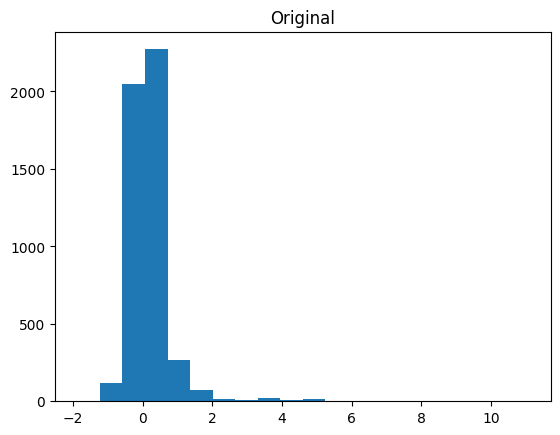

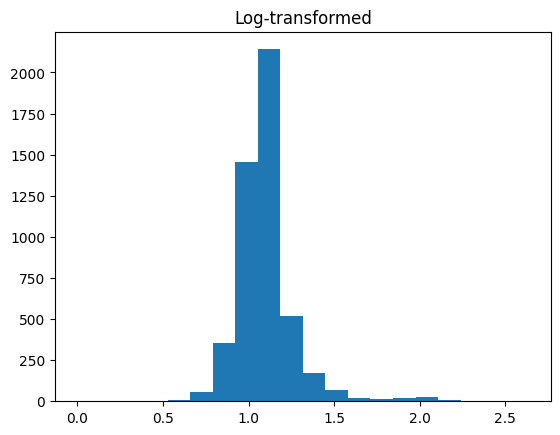

Applied log1p transform (shift=-1.869).


In [26]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")


# CROSS-VAL SPLITS


Using block size of 5 time steps for CV splits.

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.099–0.101


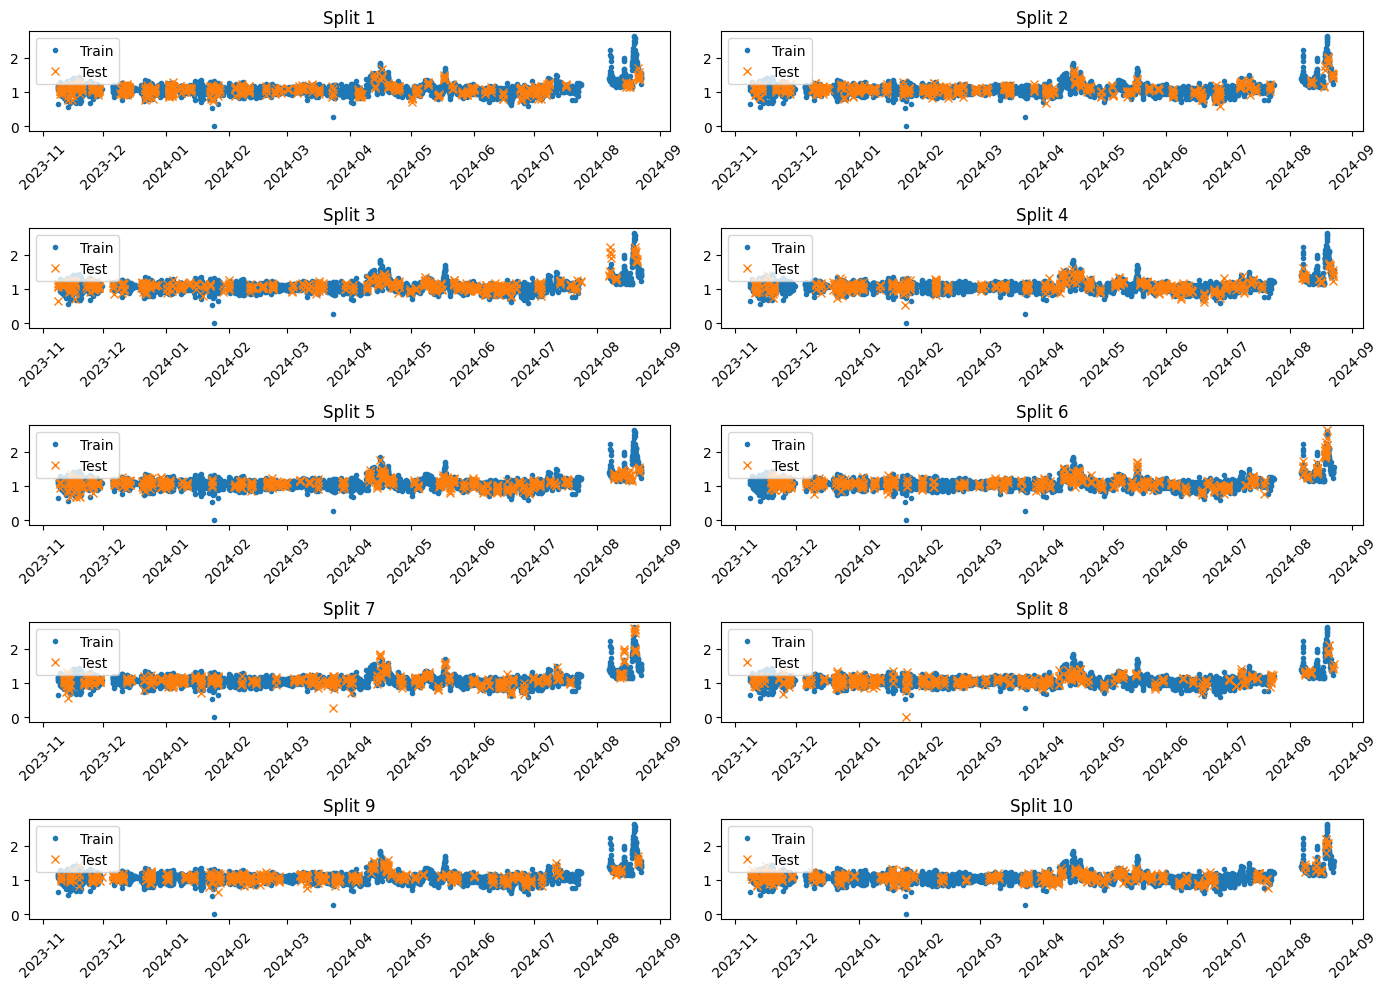

In [27]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6) # quantile 0.9 is a conservative choice
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# FEATURE SELECTION

In [28]:
# Model factory
def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    elif MODEL_TYPE == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    else:
        raise ValueError("MODEL_TYPE must be 'RandomForest' or 'XGBoost'")

model_factory()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

Iter 1: kept=200 removed=['timesince_fert_org', 'timesince_fert_min', 'trt', 'NEE_L3.3_CUT_50_QCF_gfXGBoost', 'SW_IN_POT', 'NEE_L3.3_CUT_50_QCF_gfXGBoost_lag9h', 'NEE_L3.3_CUT_50_QCF_gfXGBoost_lag3h_roll6hsum', 'NEE_L3.3_CUT_50_QCF_gfXGBoost_lag6h', 'NEE_L3.3_CUT_50_QCF_gfXGBoost_lag3h', 'NEE_L3.3_CUT_50_QCF_gfXGBoost_lag6h_roll9hsum'] RMSE_oof=0.3677 R2_oof=0.7637
Iter 2: kept=190 removed=['NEE_L3.3_CUT_50_QCF0_gfXGBoost', 'GPP_NT_CUT_50_gfXG_QCF0_lag9h', 'GPP_NT_CUT_50_gfXG_QCF0_lag3h', 'GPP_NT_CUT_50_gfXG_QCF0_lag6h', 'prec_lag3h', 'NEE_L3.3_CUT_50_QCF_gfXGBoost_lag6h_roll6hsum', 'NEE_L3.3_CUT_50_QCF_gfXGBoost_lag6h_roll3hsum', 'ts_0.05_gfXG_lag6h', 'prec', 'ta_lag6h_roll9hmean'] RMSE_oof=0.3584 R2_oof=0.7756
Iter 3: kept=180 removed=['RECO_NT_CUT_50_gfXG_QCF0', 'timesince_fert', 'ta_roll9hmean', 'prec_lag3h_roll3hsum', 'ta_lag3h', 'wfps_0.3_gfXG_lag9h', 'ts_0.15_gfXG_diff12h', 'GPP_NT_CUT_50_gfXG_QCF0_lag6h_roll3hsum', 'ta_lag9h', 'prec_lag9h'] RMSE_oof=0.3573 R2_oof=0.7769
Iter 4:

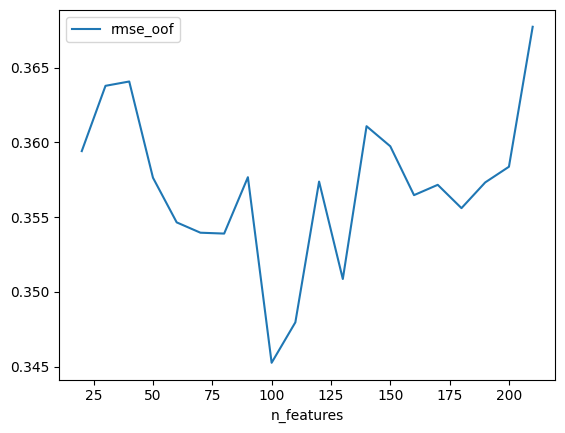

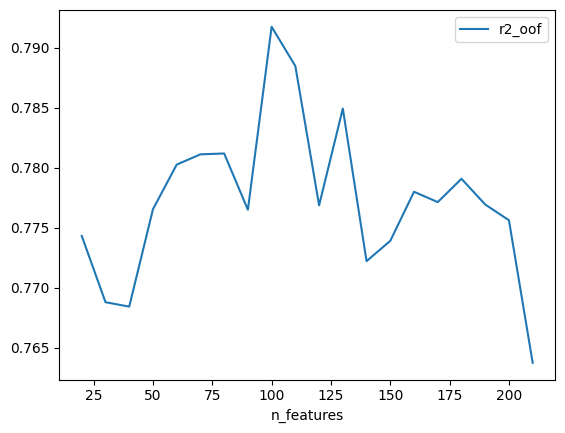

In [29]:
best_feats, ranking, hist = rfe_selection(
    X, y, splits,
    model_factory=model_factory,
    inv_y=inv_fn if LOG_TRANSFORM else None,
    step=10,           # try 5 or 10 if it’s slow
    min_features=10,
    verbose=True,
    score_mode='composite',  # 'rmse' or 'composite',
    w_penalty = 0.001
)

# optional plot in notebook
hist.plot(x="n_features", y="rmse_oof");
hist.plot(x="n_features", y="r2_oof");

print(f"\nBest features selected:\n{best_feats}")
print(f"\nFeature ranking:\n{ranking}")


# EXPORT 

In [30]:
filename = f"best_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in best_feats:
        f.write(f"{item}\n")
print("Wrote:", filename)

filename = f"ranked_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in ranking:
        f.write(f"{item}\n")
print("Wrote:", filename)


Wrote: best_features_FN2O_XGBoost.txt
Wrote: ranked_features_FN2O_XGBoost.txt


# **End of notebook**

In [31]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-02-11 18:52:31
